In [1]:
# ==== Paths & Imports (robust) ====
import os, sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import pandas as pd
import cv2


def add_repo_root(pkg_name="kaggle"):
    here = Path(os.getcwd()).resolve()
    for p in [here] + list(here.parents):
        if (p / pkg_name / "__init__.py").exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return str(p)
    raise FileNotFoundError(
        f"Could not find repo root containing {pkg_name}/__init__.py from {here}"
    )


ROOT = add_repo_root("kaggle")
print("Project root:", ROOT)

from kaggle.code.dataset import SegDataset, get_transforms
from kaggle.code.model import build_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(
    "Torch:",
    torch.__version__,
    "| CUDA:",
    torch.cuda.is_available(),
    "| device:",
    device,
)

Project root: /homes/nfs/ben/project/AI-pruning-project
Torch: 2.5.1+cu121 | CUDA: True | device: cuda


In [2]:
# ==== Config ====
DATA_ROOT = os.path.join(ROOT, "kaggle", "data")
TEST_IMG_DIR = os.path.join(DATA_ROOT, "test", "imgs")
SAVE_DIR = os.path.join(ROOT, "kaggle")
FIG_DIR = os.path.join(ROOT, "kaggle", "fig")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

CFG = {
    "model_name": "DeepLabV3Plus",  # must match training
    "encoder": "resnet101",  # must match training
    "num_classes": 16,
    "pretrained": False,  # not needed at inference if loading weights
    "batch_size": 8,
    "num_workers": 2,
    "tta_hflip": True,  # simple TTA: horizontal flip
    "orig_size": (1024, 1024),  # (H, W) original dataset size
    "ckpt_path": os.path.join(SAVE_DIR, "best_model.pth"),
    "out_csv": os.path.join(ROOT, "kaggle", "submission.csv"),
}
print(CFG)
assert os.path.exists(TEST_IMG_DIR), f"Missing: {TEST_IMG_DIR}"
assert os.path.exists(CFG["ckpt_path"]), f"Missing checkpoint: {CFG['ckpt_path']}"

{'model_name': 'DeepLabV3Plus', 'encoder': 'resnet101', 'num_classes': 16, 'pretrained': False, 'batch_size': 8, 'num_workers': 2, 'tta_hflip': True, 'orig_size': (1024, 1024), 'ckpt_path': '/homes/nfs/ben/project/AI-pruning-project/kaggle/best_model.pth', 'out_csv': '/homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv'}


In [3]:
# ==== Test Dataset & DataLoader ====
test_tf = get_transforms("val")  # deterministic resize+normalize
test_set = SegDataset(TEST_IMG_DIR, mask_dir=None, transform=test_tf)
test_loader = DataLoader(
    test_set,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
)
len(test_set)

1000

In [4]:
# ==== Build model & Load checkpoint ====
model = build_model(
    model_name=CFG["model_name"],
    encoder=CFG["encoder"],
    num_classes=CFG["num_classes"],
    pretrained=False,
).to(device)

state = torch.load(CFG["ckpt_path"], map_location=device)
model.load_state_dict(state)
model.eval()
print("Loaded weights from:", CFG["ckpt_path"])

/tmp/ipykernel_36077/1356189064.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CFG["ckpt_path"], map_location=device)


Loaded weights from: /homes/nfs/ben/project/AI-pruning-project/kaggle/best_model.pth


In [5]:
# ==== RLE helper ====
import numpy as np


def rle_encode(mask: np.ndarray) -> str:
    # mask: binary {0,1} array (H,W)
    pixels = mask.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[:-1:2]
    return " ".join(map(str, runs))

In [6]:
# ==== Inference & Submission Building ====
from tqdm.auto import tqdm

H, W = CFG["orig_size"]
records = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        imgs, names = batch  # Dataset returns (img, fname) when mask_dir=None
        imgs = imgs.to(device)

        # base prediction
        logits = model(imgs)

        if CFG["tta_hflip"]:
            logits_flip = model(torch.flip(imgs, dims=[3]))
            logits = (logits + torch.flip(logits_flip, dims=[3])) / 2

        preds = torch.argmax(logits, dim=1).cpu().numpy().astype(np.uint8)

        for pred, fname in zip(preds, names):
            # resize back to original size (1024x1024) with nearest-neighbor
            pred = cv2.resize(pred, (W, H), interpolation=cv2.INTER_NEAREST)

            row = {"img": fname}
            for c in range(CFG["num_classes"]):
                m = (pred == c).astype(np.uint8)
                row[f"class_{c}"] = "none" if m.sum() == 0 else rle_encode(m)
            records.append(row)

df = pd.DataFrame(records)
df.to_csv(CFG["out_csv"], index=False)
print("Saved:", CFG["out_csv"], "Rows:", len(df))
df.head()

Predicting:   0%|          | 0/125 [00:00<?, ?it/s]

Saved: /homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv Rows: 1000


,img,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9,class_10,class_11,class_12,class_13,class_14,class_15
0,4000.png,1 360 373 46 1025 360 1397 46 2049 360 2421 54...,361 12 419 140 895 18 957 24 1385 12 1443 140 ...,621181 8 622205 8 623227 16 624251 16 625273 2...,799 96 913 44 981 44 1823 96 1937 44 2005 44 2...,559 184 1583 184 2607 126 2741 8 2751 40 3631 ...,none,743 56 1767 56 2791 56 3815 56 4839 56 5863 56...,none,2749 2 3773 2 4793 10 5817 10 6839 22 7863 22 ...,314025 24 315049 24 316021 12 316061 44 317045...,766541 2 767565 2 768587 6 769611 6 770635 8 7...,none,658043 6 659067 6 660091 10 661115 10 662139 1...,none,none,none
1,4001.png,1 362 367 52 717 18 1025 362 1391 52 1741 18 2...,363 4 419 140 901 2 957 22 1387 4 1443 140 192...,625279 14 626303 14 627327 18 628351 18 629375...,799 102 903 54 979 46 1823 102 1927 54 2003 46...,559 158 735 10 1583 158 1759 10 2607 158 2779 ...,901627 2 902651 2 903673 6 904697 6 905719 8 9...,745 54 1769 54 2791 56 3815 56 4839 56 5863 56...,none,396055 4 397079 4 398101 8 399125 8 400149 10 ...,314021 14 315045 14 316023 12 316057 46 317047...,766541 2 767565 2 768587 6 769611 6 770635 8 7...,none,653945 2 654969 2 655993 12 657017 12 658041 1...,981609 2 982633 2 983657 4 984681 4 985707 2 9...,none,none
2,4002.png,1 350 805 32 1025 350 1829 32 2049 350 2855 28...,351 270 949 8 1375 270 1973 8 2399 270 2997 6 ...,582057 4 582647 4 583081 4 583671 4 584103 8 5...,727 2 735 38 837 10 895 54 957 68 1751 2 1759 ...,621 106 729 6 773 32 1645 106 1753 6 1797 32 2...,none,847 48 1871 48 2893 50 3917 50 4937 52 5961 52...,none,6965 4 7989 4 9009 10 10033 10 11057 10 12081 ...,266811 4 267835 4 268857 6 269881 6 270901 10 ...,710939 8 711963 8 712985 14 714009 14 715029 2...,none,743787 2 744811 2 745833 6 746857 6 747881 10 ...,929993 4 931017 4 932039 6 933063 6 934087 6 9...,none,none
3,4003.png,1 298 1025 298 2049 298 3073 298 4097 298 5121...,299 322 1323 322 2347 322 3371 322 4395 320 54...,495989 4 497013 4 498035 10 499059 10 500081 1...,621 162 845 180 1645 162 1869 180 2669 162 289...,479559 4 480583 4 481609 6 482633 6 483657 8 4...,436467 2 437491 2 438515 2 439539 2 440563 2 4...,783 62 1807 62 2831 64 3855 64 4877 66 5901 66...,none,250587 2 251611 2 252633 6 253657 6 254679 12 ...,168535 24 169559 24 170581 30 171605 30 172627...,667867 2 668891 2 669913 6 670937 6 671961 8 6...,none,684337 6 685361 6 686385 6 687409 6 688433 6 6...,929895 8 930919 8 931939 16 932963 16 933985 1...,none,none
4,4004.png,1 136 139 68 429 134 645 152 1025 136 1163 68 ...,137 2 207 222 933 82 1161 2 1231 222 1957 82 2...,373343 6 374367 6 375391 10 376415 10 377439 1...,1015 10 2039 10 3061 12 4085 12 5107 14 6131 1...,936487 2 937511 2 938531 6 939555 6 940577 10 ...,840085 4 841109 4 842131 12 843155 12 844179 1...,387761 6 388785 6 395923 10 396947 10 782917 2...,none,797 136 1821 136 2841 140 3865 140 4887 144 59...,563 82 1587 82 2607 88 3631 88 4653 94 5677 94...,391719 8 392743 8 393763 16 394787 16 395809 1...,none,572025 6 573049 6 574069 10 575093 10 576115 1...,none,none,none


In [7]:
# ==== Validate CSV structure ====
import pandas as pd
import re

df = pd.read_csv(CFG["out_csv"])
expected_cols = ["img"] + [f"class_{i}" for i in range(CFG["num_classes"])]
print("Columns OK:", list(df.columns) == expected_cols)
print("First rows:")
display(df.head())


def is_valid_rle(s):
    if s == "none":
        return True
    return re.fullmatch(r"[0-9 ]+", s) is not None and len(s.strip()) > 0


ok = df[expected_cols[1:]].applymap(is_valid_rle).all().all()
print("RLE strings valid-ish:", ok)

Columns OK: True
First rows:


,img,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9,class_10,class_11,class_12,class_13,class_14,class_15
0,4000.png,1 360 373 46 1025 360 1397 46 2049 360 2421 54...,361 12 419 140 895 18 957 24 1385 12 1443 140 ...,621181 8 622205 8 623227 16 624251 16 625273 2...,799 96 913 44 981 44 1823 96 1937 44 2005 44 2...,559 184 1583 184 2607 126 2741 8 2751 40 3631 ...,none,743 56 1767 56 2791 56 3815 56 4839 56 5863 56...,none,2749 2 3773 2 4793 10 5817 10 6839 22 7863 22 ...,314025 24 315049 24 316021 12 316061 44 317045...,766541 2 767565 2 768587 6 769611 6 770635 8 7...,none,658043 6 659067 6 660091 10 661115 10 662139 1...,none,none,none
1,4001.png,1 362 367 52 717 18 1025 362 1391 52 1741 18 2...,363 4 419 140 901 2 957 22 1387 4 1443 140 192...,625279 14 626303 14 627327 18 628351 18 629375...,799 102 903 54 979 46 1823 102 1927 54 2003 46...,559 158 735 10 1583 158 1759 10 2607 158 2779 ...,901627 2 902651 2 903673 6 904697 6 905719 8 9...,745 54 1769 54 2791 56 3815 56 4839 56 5863 56...,none,396055 4 397079 4 398101 8 399125 8 400149 10 ...,314021 14 315045 14 316023 12 316057 46 317047...,766541 2 767565 2 768587 6 769611 6 770635 8 7...,none,653945 2 654969 2 655993 12 657017 12 658041 1...,981609 2 982633 2 983657 4 984681 4 985707 2 9...,none,none
2,4002.png,1 350 805 32 1025 350 1829 32 2049 350 2855 28...,351 270 949 8 1375 270 1973 8 2399 270 2997 6 ...,582057 4 582647 4 583081 4 583671 4 584103 8 5...,727 2 735 38 837 10 895 54 957 68 1751 2 1759 ...,621 106 729 6 773 32 1645 106 1753 6 1797 32 2...,none,847 48 1871 48 2893 50 3917 50 4937 52 5961 52...,none,6965 4 7989 4 9009 10 10033 10 11057 10 12081 ...,266811 4 267835 4 268857 6 269881 6 270901 10 ...,710939 8 711963 8 712985 14 714009 14 715029 2...,none,743787 2 744811 2 745833 6 746857 6 747881 10 ...,929993 4 931017 4 932039 6 933063 6 934087 6 9...,none,none
3,4003.png,1 298 1025 298 2049 298 3073 298 4097 298 5121...,299 322 1323 322 2347 322 3371 322 4395 320 54...,495989 4 497013 4 498035 10 499059 10 500081 1...,621 162 845 180 1645 162 1869 180 2669 162 289...,479559 4 480583 4 481609 6 482633 6 483657 8 4...,436467 2 437491 2 438515 2 439539 2 440563 2 4...,783 62 1807 62 2831 64 3855 64 4877 66 5901 66...,none,250587 2 251611 2 252633 6 253657 6 254679 12 ...,168535 24 169559 24 170581 30 171605 30 172627...,667867 2 668891 2 669913 6 670937 6 671961 8 6...,none,684337 6 685361 6 686385 6 687409 6 688433 6 6...,929895 8 930919 8 931939 16 932963 16 933985 1...,none,none
4,4004.png,1 136 139 68 429 134 645 152 1025 136 1163 68 ...,137 2 207 222 933 82 1161 2 1231 222 1957 82 2...,373343 6 374367 6 375391 10 376415 10 377439 1...,1015 10 2039 10 3061 12 4085 12 5107 14 6131 1...,936487 2 937511 2 938531 6 939555 6 940577 10 ...,840085 4 841109 4 842131 12 843155 12 844179 1...,387761 6 388785 6 395923 10 396947 10 782917 2...,none,797 136 1821 136 2841 140 3865 140 4887 144 59...,563 82 1587 82 2607 88 3631 88 4653 94 5677 94...,391719 8 392743 8 393763 16 394787 16 395809 1...,none,572025 6 573049 6 574069 10 575093 10 576115 1...,none,none,none


/tmp/ipykernel_36077/704666116.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ok = df[expected_cols[1:]].applymap(is_valid_rle).all().all()


RLE strings valid-ish: True


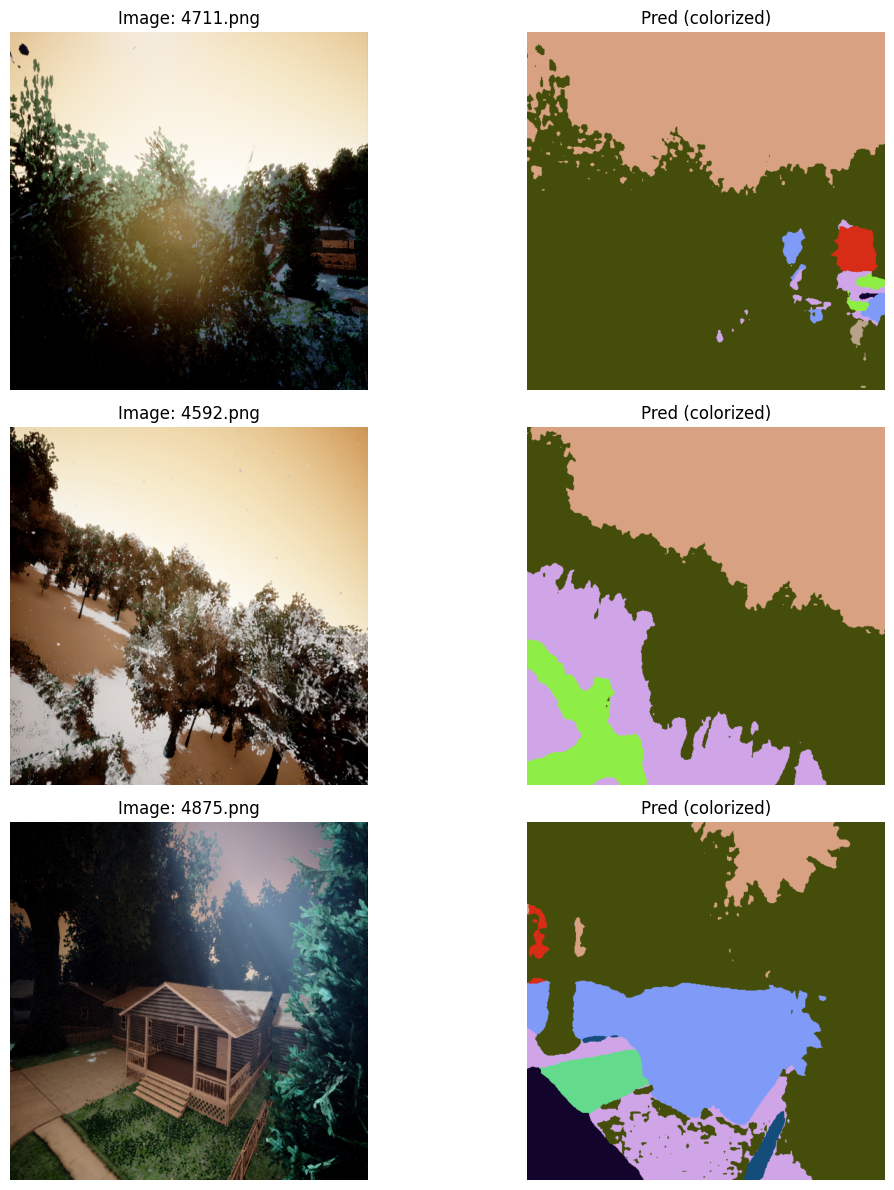

In [8]:
# ==== (Optional) Visualize a few predictions ====
import numpy as np
import matplotlib.pyplot as plt


def colorize_mask(mask, num_classes=16, seed=0):
    rng = np.random.default_rng(seed)
    palette = (rng.integers(0, 255, size=(num_classes, 3))).astype(np.uint8)
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(num_classes):
        color[mask == c] = palette[c]
    return color


n_show = 3
idxs = np.random.choice(len(test_set), size=min(n_show, len(test_set)), replace=False)
plt.figure(figsize=(12, 4 * n_show))

for i, idx in enumerate(idxs, start=1):
    img, fname = test_set[idx]
    with torch.no_grad():
        pred = (
            model(img.unsqueeze(0).to(device))
            .argmax(1)
            .squeeze(0)
            .cpu()
            .numpy()
            .astype(np.uint8)
        )
    pred = cv2.resize(pred, (W, H), interpolation=cv2.INTER_NEAREST)

    # denormalize image (visual only)
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    plt.subplot(n_show, 2, 2 * i - 1)
    plt.imshow(img_np)
    plt.title(f"Image: {fname}")
    plt.axis("off")

    plt.subplot(n_show, 2, 2 * i)
    plt.imshow(colorize_mask(pred, CFG["num_classes"]))
    plt.title("Pred (colorized)")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("Inference complete. Submission saved at:", CFG["out_csv"])

Inference complete. Submission saved at: /homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv


In [11]:
!kaggle competitions submit -c 2025-ncku-ee-ml-16-classes-segmentation -f ../submission.csv -m "fintuened deeplabv3+ resnet101"

100%|██████████████████████████████████████| 86.4M/86.4M [00:04<00:00, 18.8MB/s]
Successfully submitted to 2025 NCKU EE ML UAV Segmentation